# 🎬 TMDB Movie Recommendation System

Welcome to the notebook for building a **content-based movie recommendation system using Python and the TMDB 5000 dataset**.

This project focuses on understanding how movie information can be processed and transformed into meaningful features to recommend movies that are similar to a selected movie.

The recommendation system combines **data preprocessing, movie rating analysis, popularity analysis, feature scaling, Natural Language Processing (NLP), TF-IDF vectorization, and similarity-based recommendation**.

> **Note:** This project uses a content-based recommendation approach. It does not use Collaborative Filtering, user-item rating matrices, or SVD.

---

## Getting Started

     Let's import some libraries we will need:

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [21]:
credits = pd.read_csv("tmdb_5000_credits.csv")
credits.head(4)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."


In [22]:
movies = pd.read_csv("tmdb_5000_movies.csv")
movies.head(4)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106


In [23]:
'''

The first dataset "credits.csv" contains the following features:-

movie_id - A unique identifier for each movie.
cast - The name of lead and supporting actors.
crew - The name of Director, Editor, Composer, Writer etc.



The second dataset "movies.csv" has the following features:-

budget - The budget in which the movie was made.
genre - The genre of the movie, Action, Comedy ,Thriller etc.
homepage - A link to the homepage of the movie.
id - This is infact the movie_id as in the first dataset.
keywords - The keywords or tags related to the movie.
original_language - The language in which the movie was made.
original_title - The title of the movie before translation or adaptation.
overview - A brief description of the movie.
popularity - A numeric quantity specifying the movie popularity.
production_companies - The production house of the movie.
production_countries - The country in which it was produced.
release_date - The date on which it was released.
revenue - The worldwide revenue generated by the movie.
runtime - The running time of the movie in minutes.
status - "Released" or "Rumored".
tagline - Movie's tagline.
title - Title of the movie.
vote_average - average ratings the movie recieved.
vote_count - the count of votes recieved.

'''

'\n\nThe first dataset "credits.csv" contains the following features:-\n\nmovie_id - A unique identifier for each movie.\ncast - The name of lead and supporting actors.\ncrew - The name of Director, Editor, Composer, Writer etc.\n\n\n\nThe second dataset "movies.csv" has the following features:-\n\nbudget - The budget in which the movie was made.\ngenre - The genre of the movie, Action, Comedy ,Thriller etc.\nhomepage - A link to the homepage of the movie.\nid - This is infact the movie_id as in the first dataset.\nkeywords - The keywords or tags related to the movie.\noriginal_language - The language in which the movie was made.\noriginal_title - The title of the movie before translation or adaptation.\noverview - A brief description of the movie.\npopularity - A numeric quantity specifying the movie popularity.\nproduction_companies - The production house of the movie.\nproduction_countries - The country in which it was produced.\nrelease_date - The date on which it was released.\nre

# Step 2:-- Lets go for Data Preparation...
   

In [24]:
movies.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='str')

In [25]:
credits.columns

Index(['movie_id', 'title', 'cast', 'crew'], dtype='str')

In [26]:
print("Credits:",credits.shape)
print("movies:",movies.shape)

Credits: (4803, 4)
movies: (4803, 20)


In [27]:
credits_column_renamed =  credits.rename(columns={'movie_id':'id'}) 
credits_column_renamed

,id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...
4798,9367,El Mariachi,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,72766,Newlyweds,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,231617,"Signed, Sealed, Delivered","[{""cast_id"": 8, ""character"": ""Oliver O\u2019To...","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4801,126186,Shanghai Calling,"[{""cast_id"": 3, ""character"": ""Sam"", ""credit_id...","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


In [28]:
credits_column_renamed.shape

(4803, 4)

In [29]:
movies_df_merge = movies.merge(credits_column_renamed,on='id')

In [30]:
movies_df_merge.head(20)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
5,258000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",http://www.sonypictures.com/movies/spider-man3/,559,"[{""id"": 851, ""name"": ""dual identity""}, {""id"": ...",en,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...,115.699814,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,139.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,The battle within.,Spider-Man 3,5.9,3576,Spider-Man 3,"[{""cast_id"": 30, ""character"": ""Peter Parker / ...","[{""credit_id"": ""52fe4252c3a36847f80151a5"", ""de..."
6,260000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...",http://disney.go.com/disneypictures/tangled/,38757,"[{""id"": 1562, ""name"": ""hostage""}, {""id"": 2343,...",en,Tangled,When the kingdom's most wanted-and most charmi...,48.681969,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",..

In [31]:
movies_df_merge.shape

(4803, 23)

In [32]:
movies_df_merge.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average',
       'vote_count', 'title_y', 'cast', 'crew'],
      dtype='str')

In [33]:
movies_df_merge.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [35]:
movies_cleaned_df = movies_df_merge.drop(columns = ['homepage' , 'title_x' , 'title_y' ,'status' , 'production_countries'])
movies_cleaned_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4798,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]",1992-09-04,2040920,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]","He didn't come looking for trouble, but troubl...",6.6,238,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",72766,[],en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],2011-12-26,0,85.0,[],A newlywed couple's honeymoon is upended by th...,5.9,5,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",231617,"[{""id"": 248, ""name"": ""date""}, {""id"": 699, ""nam...",en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,"[{""name"": ""Front Street Pictures"", ""id"": 3958}..."

In [36]:
movies_cleaned_df.head(2)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [37]:
movies_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   id                    4803 non-null   int64  
 3   keywords              4803 non-null   str    
 4   original_language     4803 non-null   str    
 5   original_title        4803 non-null   str    
 6   overview              4800 non-null   str    
 7   popularity            4803 non-null   float64
 8   production_companies  4803 non-null   str    
 9   release_date          4802 non-null   str    
 10  revenue               4803 non-null   int64  
 11  runtime               4801 non-null   float64
 12  spoken_languages      4803 non-null   str    
 13  tagline               3959 non-null   str    
 14  vote_average          4803 non-null   float64
 15  vote_count            4803 non-n

# Using weighted average for each movies average rating>>>

![image.png](image.png)


                  Source: http://trailerpark.weebly.com/imdb-rating.html?source=post_page---------------------------

# Calculate each componenet based on the avaove formula...

In [38]:
V = movies_cleaned_df['vote_count']
R = movies_cleaned_df['vote_average']
C = movies_cleaned_df['vote_count'].mean()

In [40]:
C
## mean rating for all the movies is approx 6.09 on a scale of 10

np.float64(690.2179887570269)

In [41]:
#### The next step is to determine an appropriate value for m ( minimum votes required to be listed in the chart)..

In [42]:
movies_cleaned_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew'],
      dtype='str')

In [43]:
movies_cleaned_df[['original_title','vote_count']]

,original_title,vote_count
0,Avatar,11800
1,Pirates of the Caribbean: At World's End,4500
2,Spectre,4466
3,The Dark Knight Rises,9106
4,John Carter,2124
...,...,...
4798,El Mariachi,238
4799,Newlyweds,5
4800,"Signed, Sealed, Delivered",6
4801,Shanghai Calling,7


<Axes: xlabel='vote_count'>

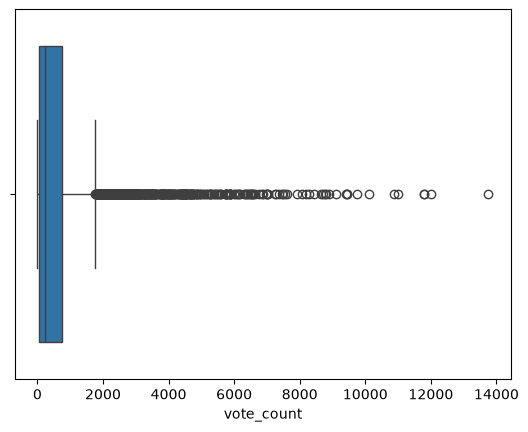

In [45]:
sns.boxplot(data= movies_cleaned_df,x = 'vote_count')

In [46]:
## m = 1900

In [47]:
'''

We will use 95th percentile as our cutoff. 
In other words, for a movie to feature in the charts, 
It must have more votes than at least 95% of the movies in the list.

'''

'\n\nWe will use 95th percentile as our cutoff. \nIn other words, for a movie to feature in the charts, \nIt must have more votes than at least 95% of the movies in the list.\n\n'

# 4.. Building Average Weighted Recommendation System !

In [ ]:
'''
m --- minimum vote required to be listed in top 250 (currentally 3000) from the avove weighted image and formula---

'''

'm --- minimum vote required to be listed in top 250 (currentally 3000) from the avove weighted image and formula---'

In [51]:
m = movies_cleaned_df['vote_count'].quantile(q = 0.95)
m

np.float64(3040.8999999999996)

In [52]:
filtered_df = movies_cleaned_df[movies_cleaned_df['vote_count'] >=m]

In [53]:
filtered_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
5,258000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",559,"[{""id"": 851, ""name"": ""dual identity""}, {""id"": ...",en,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...,115.699814,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2007-05-01,890871626,139.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",The battle within.,5.9,3576,"[{""cast_id"": 30, ""character"": ""Peter Parker / ...","[{""credit_id"": ""52fe4252c3a36847f80151a5"", ""de..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3454,6000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",629,"[{""id"": 3703, ""name"": ""law""}, {""id"": 5493, ""na...",en,The Usual Suspects,"Held in an L.A. interrogation room, Verbal Kin...",64.025031,"[{""name"": ""Blue Parrot Productions"", ""id"": 361...",1995-07-19,23341568,106.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}, ...",Five Criminals. One Line Up. No Coincidence.,8.1,3254,"[{""cast_id"": 19, ""character"": ""Michael McManus...","[{""credit_id"": ""52fe4260c3a36847f8019ad7"", ""de..."
3573,9000000,"[{""id"": 9648, ""name"": ""Mystery""}, {""id"": 53, ""...",77,"[{""id"": 30, ""name"": ""individual""}, {""id"": 328,...",en,Memento,Suffering short-term memory loss after a head ...,60.715151,"[{""name"": ""Summit Entertainment"", ""id"": 491}, ...",2000-10-11,39723096,113.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Some memories are best forgotten.,8.1,4028,"[{""cast_id"": 4, ""character"": ""Leonard"", ""credi...","[{""credit_id"": ""52fe4214c3a36847f80024d1"", ""de..."
3706,6000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 18, ""na...",141,"[{""id"": 970, ""name"": ""parents kids r

In [54]:
m

np.float64(3040.8999999999996)

In [55]:
R

0       7.2
1       6.9
2       6.3
3       7.6
4       6.1
       ... 
4798    6.6
4799    5.9
4800    7.0
4801    5.7
4802    6.3
Name: vote_average, Length: 4803, dtype: float64

In [56]:
C

np.float64(690.2179887570269)

In [57]:
V

0       11800
1        4500
2        4466
3        9106
4        2124
        ...  
4798      238
4799        5
4800        6
4801        7
4802       16
Name: vote_count, Length: 4803, dtype: int64

In [59]:
movies_cleaned_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew'],
      dtype='str')

In [65]:
v = filtered_df['vote_count']
R = filtered_df['vote_average']
c = filtered_df['vote_count'].mean()

In [66]:
v

0       11800
1        4500
2        4466
3        9106
5        3576
        ...  
3454     3254
3573     4028
3706     3452
3865     4254
4300     3697
Name: vote_count, Length: 241, dtype: int64

In [67]:
R

0       7.2
1       6.9
2       6.3
3       7.6
5       5.9
       ... 
3454    8.1
3573    8.1
3706    7.7
3865    8.3
4300    8.0
Name: vote_average, Length: 241, dtype: float64

In [68]:
c

np.float64(5001.253112033195)

In [76]:
filtered_df['weighted_avg'] = ((R*v) + (C*m))/(v+m)



In [77]:
filtered_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",1030.481345
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",2020.894136
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",2029.658899
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",1257.729642
5,258000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",559,"[{""id"": 851, ""name"": ""dual identity""}, {""id"": ...",en,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...,115.699814,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2007-05-01,890871626,139.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",The battle within.,5.9,3576,"[{""cast_id"": 30, ""character"": ""Peter Parker / ...","[{""credit_id"": ""52fe4252c3a36847f80151a5"", ""de...",2301.592738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3454,6000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",629,"[{""id"": 3703, ""name"": ""law""}, {""id"": 5493, ""na...",en,The Usual Suspects,"Held in an L.A. interrogation room, Verbal Kin...",64.025031,"[{""name"": ""Blue Parrot Productions"", ""id"": 361...",1995-07-19,23341568,106.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}, ...",Five Criminals. One Line Up. No Coincidence.,8.1,3254,"[{""cast_id"": 19, ""character"": ""Michael McManus...","[{""credit_id"": ""52fe4260c3a36847f8019ad7"", ""de...",2420.160446
3573,9000000,"[{""id"": 9648, ""name"": ""Mystery""}, {""id"": 53, ""...",77,"[{""id"": 30, ""name"": ""individual""}, {""id"": 328,...",en,Memento,Suffering short-term memory loss after a head ...,60.715151,"[{""name"": ""Summit Entertainment"", ""id"": 491}, ...",2000-10-11,39723096,113.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Some memories are best forgotten.,8.1,4028,"[{""cast_id"": 4, ""character"": ""Leonard"", ""credi...","[{""credit_id"": ""52fe4214c3a36847f80024d1"", ""de...",2156.055028
3706,6000000,"[{""i

In [78]:
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
      dtype='str')

In [79]:
sorting_rankong_df = filtered_df.sort_values('weighted_avg',ascending=False).head(10)

In [80]:
sorting_rankong_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg
2465,19000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 18, ""na...",1417,"[{""id"": 514, ""name"": ""spain""}, {""id"": 836, ""na...",es,El laberinto del fauno,Living with her tyrannical stepfather in a new...,90.809408,"[{""name"": ""Estudios Picasso"", ""id"": 2029}, {""n...",2006-05-27,83258226,118.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",What happens when make-believe believes it's r...,7.6,3041,"[{""cast_id"": 1, ""character"": ""Ofelia"", ""credit...","[{""credit_id"": ""571025c09251410832001052"", ""de...",2504.385503
2178,15000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 18, ""...",5915,"[{""id"": 255, ""name"": ""male nudity""}, {""id"": 97...",en,Into the Wild,"The true story of top student and athlete, Chr...",43.644978,"[{""name"": ""Paramount Vantage"", ""id"": 838}, {""n...",2007-09-11,56255142,148.0,"[{""iso_639_1"": ""da"", ""name"": ""Dansk""}, {""iso_6...",Into the heart. Into the soul.,7.8,3045,"[{""cast_id"": 15, ""character"": ""Christopher McC...","[{""credit_id"": ""57190512c3a3687b8c004a60"", ""de...",2502.844540
1008,49000000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 28, ""name...",198184,"[{""id"": 310, ""name"": ""artificial intelligence""...",en,Chappie,Every child comes into the world full of promi...,116.700319,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-03-04,104399548,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",I am consciousness. I am alive. I am Chappie.,6.6,3062,"[{""cast_id"": 2, ""character"": ""Chappie"", ""credi...","[{""credit_id"": ""55594b54925141785200063f"", ""de...",2495.292367
1559,29000000,"[{""id"": 10749, ""name"": ""Romance""}, {""id"": 18, ...",11036,"[{""id"": 493, ""name"": ""poem""}, {""id"": 1261, ""na...",en,The Notebook,An epic love story centered around an older ma...,55.109138,"[{""name"": ""New Line Cinema"", ""id"": 12}]",2004-06-25,115603229,123.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Behind every great love is a great story.,7.7,3067,"[{""cast_id"": 4, ""character"": ""Allie Hamilton"",...","[{""credit_id"": ""52fe43e89251416c75022af1"", ""de...",2493.807444
744,60000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 16, ""...",137106,"[{""id"": 494, ""name"": ""father son relationship""...",en,The Lego Movie,"An ordinary Lego mini-figure, mistakenly thoug...",59.547928,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",2014-02-06,469160692,100.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The story of a nobody who saved everybody.,7.5,3070,"[{""cast_id"": 16, ""character"": ""Emmet Brickowsk...","[{""credit_id"": ""53a44a6cc3a3682a4200128a"", ""de...",2492.486473
1051,46000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 53, ""name...",146233,"[{""id"": 904, ""name"": ""pennsylvania""}, {""id"": 1...",en,Prisoners,When Keller Dover's daughter and her friend go...,88.496873,"[{""name"": ""Alcon Entertainment"", ""id"": 1088}, ...",2013-09-18,122126687,153.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Every moment matters.,7.9,3085,"[{""cast_id"": 2, ""character"": ""Keller Dover"", ""...","[{""credit_id"": ""52fe4b799251416c75103f71"", ""de...",2486.603126
1813,33000000,"[{""id"": 18, ""name"": ""Drama""}]",13223,"[{""id"": 570, ""name"": ""rape""}, {""id"": 1543, ""na...",en,Gran Torino,Walt Kowalski is a widower who holds onto his ...,50.745300,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",2008-12-09,269958228,116.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Ever come across somebody you shouldn't have m...,7.8,3086,"[{""cast_id"": 1, ""character"": ""Walt Kowalski"", ...","[{""credit_id"": ""52fe45509251416c75052449"", ""de...",2486.148197
1366,35000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",350,"[{""id"": 90, ""name

In [81]:
sorting_rankong_df[['original_title' , 'vote_average', 'vote_count' , 'weighted_avg' , 'popularity']]

,original_title,vote_average,vote_count,weighted_avg,popularity
2465,El laberinto del fauno,7.6,3041,2504.385503,90.809408
2178,Into the Wild,7.8,3045,2502.844540,43.644978
1008,Chappie,6.6,3062,2495.292367,116.700319
1559,The Notebook,7.7,3067,2493.807444,55.109138
744,The Lego Movie,7.5,3070,2492.486473,59.547928
1051,Prisoners,7.9,3085,2486.603126,88.496873
1813,Gran Torino,7.8,3086,2486.148197,50.745300
1366,The Devil Wears Prada,7.0,3088,2484.936381,83.893257
2096,The Conjuring,7.4,3092,2483.521888,49.975409
36,Transformers: Age of Extinction,5.8,3095,2481.504195,116.840296


In [82]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

<Axes: xlabel='weighted_avg', ylabel='original_title'>

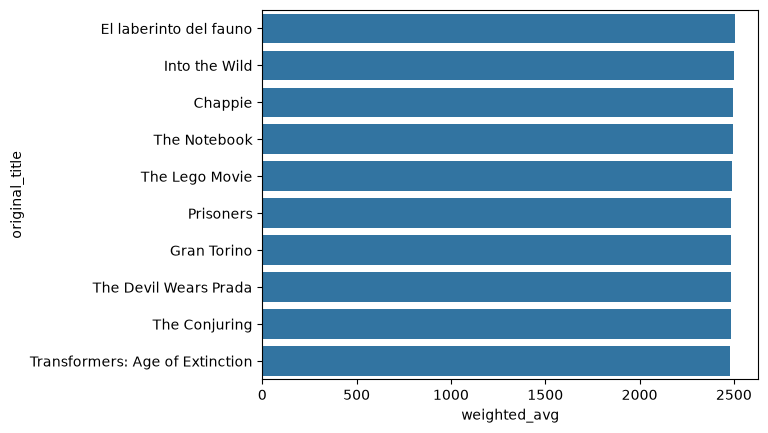

In [83]:
sns.barplot(x = sorting_rankong_df['weighted_avg'],y = sorting_rankong_df['original_title'])

# 5.. Building Popularity based Recommender System !

In [84]:
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
      dtype='str')

In [85]:
popularity_df = filtered_df.sort_values('popularity',ascending=False)

In [86]:
popularity_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg
546,74000000,"[{""id"": 10751, ""name"": ""Family""}, {""id"": 16, ""...",211672,"[{""id"": 3487, ""name"": ""assistant""}, {""id"": 179...",en,Minions,"Minions Stuart, Kevin and Bob are recruited by...",875.581305,"[{""name"": ""Universal Pictures"", ""id"": 33}, {""n...",2015-06-17,1156730962,91.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Before Gru, they had a history of bad bosses",6.4,4571,"[{""cast_id"": 22, ""character"": ""Scarlet Overkil...","[{""credit_id"": ""5431b2b10e0a2656e20026c7"", ""de...",2001.808351
95,165000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 18, ""...",157336,"[{""id"": 83, ""name"": ""saving the world""}, {""id""...",en,Interstellar,Interstellar chronicles the adventures of a gr...,724.247784,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...",2014-11-05,675120017,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Mankind was born on Earth. It was never meant ...,8.1,10867,"[{""cast_id"": 9, ""character"": ""Joseph Cooper"", ...","[{""credit_id"": ""52fe4bbf9251416c910e4801"", ""de...",1099.830549
788,58000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",293660,"[{""id"": 2095, ""name"": ""anti hero""}, {""id"": 307...",en,Deadpool,Deadpool tells the origin story of former Spec...,514.569956,"[{""name"": ""Twentieth Century Fox Film Corporat...",2016-02-09,783112979,108.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Witness the beginning of a happy ending,7.4,10995,"[{""cast_id"": 99, ""character"": ""Wade Wilson / D...","[{""credit_id"": ""56c986b2925141172f0068b6"", ""de...",1089.326198
94,170000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 878, ""na...",118340,"[{""id"": 8828, ""name"": ""marvel comic""}, {""id"": ...",en,Guardians of the Galaxy,"Light years from Earth, 26 years after being a...",481.098624,"[{""name"": ""Marvel Studios"", ""id"": 420}, {""name...",2014-07-30,773328629,121.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",All heroes start somewhere.,7.9,9742,"[{""cast_id"": 1, ""character"": ""Peter Quill / St...","[{""credit_id"": ""538ce329c3a3687155003358"", ""de...",1195.759365
127,150000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",76341,"[{""id"": 2964, ""name"": ""future""}, {""id"": 3713, ...",en,Mad Max: Fury Road,An apocalyptic story set in the furthest reach...,434.278564,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",2015-05-13,378858340,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",What a Lovely Day.,7.2,9427,"[{""cast_id"": 2, ""character"": ""Max Rockatansky""...","[{""credit_id"": ""577da370c3a36817f8003838"", ""de...",1225.241219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,150000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",2080,"[{""id"": 417, ""name"": ""corruption""}, {""id"": 185...",en,X-Men Origins: Wolverine,"After seeking to live a normal life, Logan set...",5.954334,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-04-28,373062864,107.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Witness the Origin.,6.2,4021,"[{""cast_id"": 3, ""character"": ""Logan / Wolverin...","[{""credit_id"": ""52fe4333c3a36847f8041de9"", ""de...",2157.102308
511,75000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",36657,"[{""id"": 1852, ""name"": ""mutant""}, {""id"": 8828, ...",en,X-Men,"Two mutants, Rogue and Wolverine, come to a pr...",4.668910,"[{""name"": ""Twentieth Century Fox Film Corporat...",2000-07-13,296339527,104.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Evolution Begins,6.8,4097,"[{""cast_id"": 5, ""character"": ""Charles Xavier /...","[{""credit_id"": ""52fe45fe9251416c910457f7"", ""de...",2134.545201
33,210000000,"[{""id"": 12, ""name"": ""Adventure""}, {""i

<Axes: ylabel='original_title'>

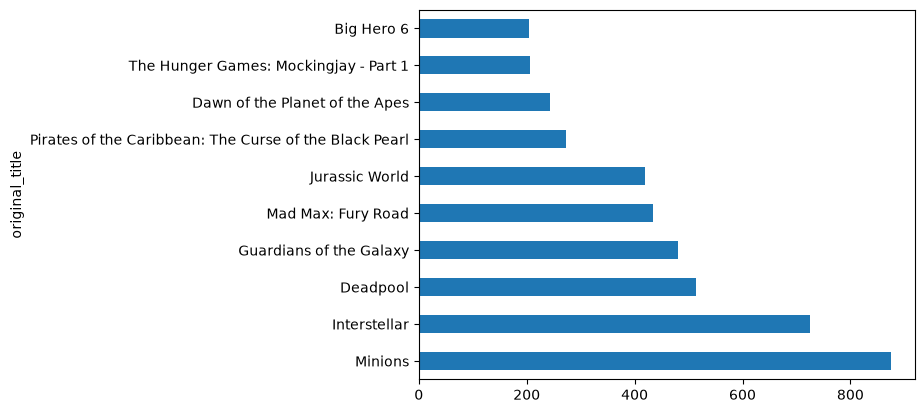

In [87]:
popularity_df.set_index('original_title')['popularity'][0:10].plot(kind='barh')

# Step 6:- How to perform Normalizaion

In [88]:
filtered_df.shape

(241, 19)

In [89]:
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
      dtype='str')

In [95]:
filtered_df[['weighted_avg','popularity']][0:10]


,weighted_avg,popularity
0,1030.481345,150.437577
1,2020.894136,139.082615
2,2029.658899,107.376788
3,1257.729642,112.312950
5,2301.592738,115.699814
6,2391.020513,48.681969
7,1555.655103,134.279229
8,1829.573044,98.885637
9,1518.007485,155.790452
12,1839.654465,145.847379


In [96]:
from sklearn.preprocessing import MinMaxScaler

In [97]:
scaling = MinMaxScaler()

In [99]:
scaling_value = scaling.fit_transform(filtered_df[['weighted_avg','popularity']])

In [111]:
filtered_df[['weighted_avg_scaled','popularity_scaled']] = scaling_value

In [112]:
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'score_max', 'weighted_avg_scaled', 'popularity_scaled'],
      dtype='str')

In [113]:
filtered_df.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg,score_max,weighted_avg_scaled,popularity_scaled
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",0.169089,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",0.074246,0.121668,0.074246,0.169089
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",0.156078,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",0.696321,0.426200,0.696321,0.156078
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,0.119748,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",0.701826,0.410787,0.701826,0.119748
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,0.125404,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",0.216980,0.171192,0.216980,0.125404
5,258000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",559,"[{""id"": 851, ""name"": ""dual identity""}, {""id"": ...",en,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...,0.129285,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2007-05-01,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",The battle within.,5.9,3576,"[{""cast_id"": 30, ""character"": ""Peter Parker / ...","[{""credit_id"": ""52fe4252c3a36847f80151a5"", ""de...",0.872627,0.500956,0.872627,0.129285


# 7.. Building a Hybrid Recommendation Model Using Weighted Average & Popularity Score !

In [114]:
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'score_max', 'weighted_avg_scaled', 'popularity_scaled'],
      dtype='str')

In [123]:
filtered_df['score_mix'] = filtered_df['weighted_avg_scaled'] * 0.5 + filtered_df['popularity_scaled'] * 0.5

In [124]:
filtered_df['score_mix']

0       0.121668
1       0.426200
2       0.410787
3       0.171192
5       0.500956
          ...   
3454    0.508586
3573    0.423748
3706    0.483806
3865    0.478406
4300    0.460427
Name: score_mix, Length: 241, dtype: float64

In [125]:
filtered_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,tagline,vote_average,vote_count,cast,crew,weighted_avg,score_max,weighted_avg_scaled,popularity_scaled,score_mix
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",0.169089,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,...,Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",0.074246,0.121668,0.074246,0.169089,0.121668
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",0.156078,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,...,"At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",0.696321,0.426200,0.696321,0.156078,0.426200
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,0.119748,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,...,A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",0.701826,0.410787,0.701826,0.119748,0.410787
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,0.125404,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,...,The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",0.216980,0.171192,0.216980,0.125404,0.171192
5,258000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",559,"[{""id"": 851, ""name"": ""dual identity""}, {""id"": ...",en,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...,0.129285,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2007-05-01,...,The battle within.,5.9,3576,"[{""cast_id"": 30, ""character"": ""Peter Parker / ...","[{""credit_id"": ""52fe4252c3a36847f80151a5"", ""de...",0.872627,0.500956,0.872627,0.129285,0.500956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3454,6000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",629,"[{""id"": 3703, ""name"": ""law""}, {""id"": 5493, ""na...",en,The Usual Suspects,"Held in an L.A. interrogation room, Verbal Kin...",0.070073,"[{""name"": ""Blue Parrot Productions"", ""id"": 361...",1995-07-19,...,Five Criminals. One Line Up. No Coincidence.,8.1,3254,"[{""cast_id"": 19, ""character"": ""Michael McManus...","[{""credit_id"": ""52fe4260c3a36847f8019ad7"", ""de...",0.947099,0.508586,0.947099,0.070073,0.508586
3573,9000000,"[{""id"": 9648, ""name"": ""Mystery""}, {""id"": 53, ""...",77,"[{""id"": 30, ""name"": ""individual""}, {""id"": 328,...",en,Memento,Suffering short-term memory loss after a head ...,0.066280,"[{""name"": ""Summit Entertainment"", ""id"": 491}, ...",2000-10-11,...,Some memories are best forgotten.,8.1,4028,"[{""cast_id"": 4, ""character"": ""Leonard"", ""credi...","[{""credit_id"": ""52fe4214c3a36847f80024d1"", ""de...",0.781215,0.423748,0.781215,0.066280,0.423748
3706,6000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 18, ""na...",141,"[{""id"": 970, ""name"": ""parents kids relationshi...",en,Donnie Darko,"After narrowly escaping a bizarre accident, a ...",0.066847,"[{""name"": ""Pandora Cinema"

In [126]:
rank_df = filtered_df.sort_values('score_max',ascending=False).head(10)

In [127]:
rank_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,tagline,vote_average,vote_count,cast,crew,weighted_avg,score_max,weighted_avg_scaled,popularity_scaled,score_mix
546,74000000,"[{""id"": 10751, ""name"": ""Family""}, {""id"": 16, ""...",211672,"[{""id"": 3487, ""name"": ""assistant""}, {""id"": 179...",en,Minions,"Minions Stuart, Kevin and Bob are recruited by...",1.000000,"[{""name"": ""Universal Pictures"", ""id"": 33}, {""n...",2015-06-17,...,"Before Gru, they had a history of bad bosses",6.4,4571,"[{""cast_id"": 22, ""character"": ""Scarlet Overkil...","[{""credit_id"": ""5431b2b10e0a2656e20026c7"", ""de...",0.684333,0.842167,0.684333,1.000000,0.842167
1008,49000000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 28, ""name...",198184,"[{""id"": 310, ""name"": ""artificial intelligence""...",en,Chappie,Every child comes into the world full of promi...,0.130431,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-03-04,...,I am consciousness. I am alive. I am Chappie.,6.6,3062,"[{""cast_id"": 2, ""character"": ""Chappie"", ""credi...","[{""credit_id"": ""55594b54925141785200063f"", ""de...",0.994289,0.562360,0.994289,0.130431,0.562360
36,210000000,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...",91314,"[{""id"": 9663, ""name"": ""sequel""}, {""id"": 9951, ...",en,Transformers: Age of Extinction,"As humanity picks up the pieces, following the...",0.130592,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...",2014-06-25,...,This is not war. It's extinction.,5.8,3095,"[{""cast_id"": 6, ""character"": ""Cade Yeager"", ""c...","[{""credit_id"": ""546c7de8c3a368096b001181"", ""de...",0.985628,0.558110,0.985628,0.130592,0.558110
2465,19000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 18, ""na...",1417,"[{""id"": 514, ""name"": ""spain""}, {""id"": 836, ""na...",es,El laberinto del fauno,Living with her tyrannical stepfather in a new...,0.100764,"[{""name"": ""Estudios Picasso"", ""id"": 2029}, {""n...",2006-05-27,...,What happens when make-believe believes it's r...,7.6,3041,"[{""cast_id"": 1, ""character"": ""Ofelia"", ""credit...","[{""credit_id"": ""571025c09251410832001052"", ""de...",1.000000,0.550382,1.000000,0.100764,0.550382
160,145000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",82702,"[{""id"": 494, ""name"": ""father son relationship""...",en,How to Train Your Dragon 2,The thrilling second chapter of the epic How T...,0.111540,"[{""name"": ""DreamWorks Animation"", ""id"": 521}, ...",2014-06-12,...,The training is over.,7.6,3106,"[{""cast_id"": 13, ""character"": ""Hiccup (voice)""...","[{""credit_id"": ""544b088f0e0a26747c00556f"", ""de...",0.983417,0.547479,0.983417,0.111540,0.547479
108,155000000,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...",87101,"[{""id"": 83, ""name"": ""saving the world""}, {""id""...",en,Terminator Genisys,"The year is 2029. John Connor, leader of the r...",0.228221,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...",2015-06-23,...,Reset the future,5.8,3631,"[{""cast_id"": 1, ""character"": ""The Terminator"",...","[{""credit_id"": ""5605f91d925141306000071e"", ""de...",0.860706,0.544464,0.860706,0.228221,0.544464
1051,46000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 53, ""name...",146233,"[{""id"": 904, ""name"": ""pennsylvania""}, {""id"": 1...",en,Prisoners,When Keller Dover's daughter and her friend go...,0.098114,"[{""name"": ""Alcon Entertainment"", ""id"": 1088}, ...",2013-09-18,...,Every moment matters.,7.9,3085,"[{""cast_id"": 2, ""character"": ""Keller Dover"", ""...","[{""credit_id"": ""52fe4b799251416c75103f71"", ""de...",0.988831,0.543473,0.988831,0.098114,0.543473
150,140000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",608,"[{""id"": 83, ""name"": ""saving the world""}, {""id""...",en,Men in Black II,"Kay and Jay reunite to provide our best, last ...",0.101364,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",20

In [128]:
import plotly.express as px

In [129]:
px.bar(data_frame=rank_df,x = 'original_title',y = 'score_mix')

# 8.. Applying TF-IDF(NLP) on text data !

In [130]:
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'score_max', 'weighted_avg_scaled', 'popularity_scaled', 'score_mix'],
      dtype='str')

In [131]:
df = filtered_df.copy()

In [133]:
df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'score_max', 'weighted_avg_scaled', 'popularity_scaled', 'score_mix'],
      dtype='str')

In [134]:
df['overview'][3]

"Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police Department. Eight years later, Batman encounters the mysterious Selina Kyle and the villainous Bane, a new terrorist leader who overwhelms Gotham's finest. The Dark Knight resurfaces to protect a city that has branded him an enemy."

In [136]:
df['overview'].isnull().sum()

np.int64(0)

In [137]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [138]:
tfidfv = TfidfVectorizer(min_df = 3,max_features=None,stop_words='english',ngram_range=(1,3))

In [139]:
tfidfv

,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",3
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'


In [140]:
tfidfv_matrix = tfidfv.fit_transform(df['overview'])

In [141]:
tfidfv_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3267 stored elements and shape (241, 610)>

In [142]:
tfidfv_matrix.shape

(241, 610)

In [143]:
df['overview'][3]

"Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police Department. Eight years later, Batman encounters the mysterious Selina Kyle and the villainous Bane, a new terrorist leader who overwhelms Gotham's finest. The Dark Knight resurfaces to protect a city that has branded him an enemy."

In [144]:
tfidfv_matrix.toarray()[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.33390581, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [147]:
pd.DataFrame(tfidfv_matrix.toarray())

,0,1,2,3,4,5,6,7,8,9,...,600,601,602,603,604,605,606,607,608,609
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.129829,0.178145,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.398671,0.0


# 9.. Applying Sigmoid Kernel to Compute Similarity Scores !

In [148]:
df['overview']

0       In the 22nd century, a paraplegic Marine is di...
1       Captain Barbossa, long believed to be dead, ha...
2       A cryptic message from Bond’s past sends him o...
3       Following the death of District Attorney Harve...
5       The seemingly invincible Spider-Man goes up ag...
                              ...                        
3454    Held in an L.A. interrogation room, Verbal Kin...
3573    Suffering short-term memory loss after a head ...
3706    After narrowly escaping a bizarre accident, a ...
3865    Under the direction of a ruthless instructor, ...
4300    A botched robbery indicates a police informant...
Name: overview, Length: 241, dtype: str

In [149]:
from sklearn.metrics.pairwise import sigmoid_kernel

In [150]:
sig = sigmoid_kernel(tfidfv_matrix,tfidfv_matrix)

In [151]:
sig

array([[0.76228178, 0.76159416, 0.76159416, ..., 0.76159416, 0.76159416,
        0.76159416],
       [0.76159416, 0.76228178, 0.76159416, ..., 0.76159416, 0.76159416,
        0.76159416],
       [0.76159416, 0.76159416, 0.76228178, ..., 0.76159416, 0.76159416,
        0.76159416],
       ...,
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76228178, 0.76159416,
        0.76159416],
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76159416, 0.76228178,
        0.76159416],
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76159416, 0.76159416,
        0.76228178]], shape=(241, 241))

In [152]:
pd.DataFrame(sig)

,0,1,2,3,4,5,6,7,8,9,...,231,232,233,234,235,236,237,238,239,240
0,0.762282,0.761594,0.761594,0.761640,0.761634,0.761594,0.761661,0.761594,0.761594,0.761594,...,0.761642,0.761594,0.761594,0.761594,0.761669,0.761594,0.761594,0.761594,0.761594,0.761594
1,0.761594,0.762282,0.761594,0.761594,0.761594,0.761594,0.761631,0.761594,0.761594,0.761679,...,0.761635,0.761594,0.761594,0.761623,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
2,0.761594,0.761594,0.762282,0.761594,0.761594,0.761594,0.761639,0.761633,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
3,0.761640,0.761594,0.761594,0.762282,0.761604,0.761630,0.761622,0.761617,0.761799,0.761594,...,0.761594,0.761594,0.761594,0.761611,0.761594,0.761594,0.761594,0.761657,0.761594,0.761628
4,0.761634,0.761594,0.761594,0.761604,0.762282,0.761594,0.761594,0.761594,0.761606,0.761594,...,0.761619,0.761653,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761671,0.761594,0.761651,...,0.761594,0.761743,0.761733,0.761759,0.761594,0.762282,0.761594,0.761594,0.761594,0.761752
237,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,...,0.761594,0.761594,0.761657,0.761594,0.761594,0.761594,0.762282,0.761594,0.761594,0.761594
238,0.761594,0.761594,0.761594,0.761657,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.762282,0.761594,0.761594
239,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761768,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.762282,0.761594


In [153]:
sig[0]

array([0.76228178, 0.76159416, 0.76159416, 0.76163963, 0.76163405,
       0.76159416, 0.76166141, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76165786, 0.76159416,
       0.76165036, 0.76159416, 0.76169467, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.7617169 , 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76163368, 0.76159416, 0.76165668,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76169718,
       0.76159416, 0.76169017, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76161898,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76161842, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159

# 10.. Building Content based Recommendation System !

In [154]:
df['original_title']

0                                         Avatar
1       Pirates of the Caribbean: At World's End
2                                        Spectre
3                          The Dark Knight Rises
5                                   Spider-Man 3
                          ...                   
3454                          The Usual Suspects
3573                                     Memento
3706                                Donnie Darko
3865                                    Whiplash
4300                              Reservoir Dogs
Name: original_title, Length: 241, dtype: str

In [155]:
df.index

Index([   0,    1,    2,    3,    5,    6,    7,    8,    9,   12,
       ...
       3158, 3232, 3234, 3337, 3439, 3454, 3573, 3706, 3865, 4300],
      dtype='int64', length=241)

In [158]:
indices = pd.Series(data = df.index,index=df['original_title'])

In [159]:
indices

original_title
Avatar                                         0
Pirates of the Caribbean: At World's End       1
Spectre                                        2
The Dark Knight Rises                          3
Spider-Man 3                                   5
                                            ... 
The Usual Suspects                          3454
Memento                                     3573
Donnie Darko                                3706
Whiplash                                    3865
Reservoir Dogs                              4300
Length: 241, dtype: int64

In [161]:
indices['Spider-Man 3']

np.int64(5)

In [163]:
sig[indices['Spider-Man 3']]

array([0.76159416, 0.76159416, 0.76159416, 0.76162962, 0.76159416,
       0.76228178, 0.76163555, 0.76159416, 0.76162793, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76161095, 0.76159416,
       0.76160878, 0.76159416, 0.76160883, 0.76159416, 0.76162815,
       0.76161789, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76162378, 0.76159416, 0.76161752,
       0.76164084, 0.76159416, 0.76162157, 0.76159416, 0.76159416,
       0.76159416, 0.76164218, 0.76159416, 0.76169116, 0.76164812,
       0.76159416, 0.76159416, 0.76162599, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76161858,
       0.76168656, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76166565, 0.76159416, 0.76166544, 0.76159416,
       0.7616869 , 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76161999, 0.76159416,
       0.76165997, 0.76159416, 0.7616411 , 0.76159416, 0.76163

In [164]:
list(enumerate(sig[indices['Spider-Man 3']]))

[(0, np.float64(0.7615941559557649)),
 (1, np.float64(0.7615941559557649)),
 (2, np.float64(0.7615941559557649)),
 (3, np.float64(0.7616296156154261)),
 (4, np.float64(0.7615941559557649)),
 (5, np.float64(0.7622817793588769)),
 (6, np.float64(0.7616355476577887)),
 (7, np.float64(0.7615941559557649)),
 (8, np.float64(0.7616279290086257)),
 (9, np.float64(0.7615941559557649)),
 (10, np.float64(0.7615941559557649)),
 (11, np.float64(0.7615941559557649)),
 (12, np.float64(0.7615941559557649)),
 (13, np.float64(0.761610952384556)),
 (14, np.float64(0.7615941559557649)),
 (15, np.float64(0.7616087833671613)),
 (16, np.float64(0.7615941559557649)),
 (17, np.float64(0.7616088251302662)),
 (18, np.float64(0.7615941559557649)),
 (19, np.float64(0.7616281541850938)),
 (20, np.float64(0.7616178912239985)),
 (21, np.float64(0.7615941559557649)),
 (22, np.float64(0.7615941559557649)),
 (23, np.float64(0.7615941559557649)),
 (24, np.float64(0.7615941559557649)),
 (25, np.float64(0.7615941559557649)

In [165]:
sigma = sorted(list(enumerate(sig[indices['Spider-Man 3']])),key=lambda x :x[1],reverse=True)

In [166]:
sigma

[(5, np.float64(0.7622817793588769)),
 (138, np.float64(0.7617191405035548)),
 (38, np.float64(0.7616911615712023)),
 (60, np.float64(0.7616868950860524)),
 (50, np.float64(0.7616865566557862)),
 (99, np.float64(0.7616837358599488)),
 (220, np.float64(0.7616831742524592)),
 (196, np.float64(0.7616758143667793)),
 (199, np.float64(0.7616698928215789)),
 (166, np.float64(0.7616676838126706)),
 (86, np.float64(0.7616667516085605)),
 (56, np.float64(0.7616656527321561)),
 (58, np.float64(0.7616654408060748)),
 (178, np.float64(0.7616648535867002)),
 (200, np.float64(0.7616637040267932)),
 (143, np.float64(0.7616634759879124)),
 (213, np.float64(0.7616606355702463)),
 (229, np.float64(0.7616602862838167)),
 (117, np.float64(0.7616600223531831)),
 (70, np.float64(0.7616599658077043)),
 (77, np.float64(0.761659421590038)),
 (193, np.float64(0.7616584894587012)),
 (84, np.float64(0.761656728653442)),
 (108, np.float64(0.7616554978678336)),
 (114, np.float64(0.7616535130788525)),
 (194, np.floa

In [167]:
sigma[0:10]

[(5, np.float64(0.7622817793588769)),
 (138, np.float64(0.7617191405035548)),
 (38, np.float64(0.7616911615712023)),
 (60, np.float64(0.7616868950860524)),
 (50, np.float64(0.7616865566557862)),
 (99, np.float64(0.7616837358599488)),
 (220, np.float64(0.7616831742524592)),
 (196, np.float64(0.7616758143667793)),
 (199, np.float64(0.7616698928215789)),
 (166, np.float64(0.7616676838126706))]

In [168]:
ind = [i[0] for i in sigma[0:10]]

In [169]:
ind

[5, 138, 38, 60, 50, 99, 220, 196, 199, 166]

In [173]:
df['original_title'].iloc[ind]

6                        Tangled
506              Despicable Me 2
55                         Brave
99      The Fast and the Furious
81                    Maleficent
228                     Oblivion
2465      El laberinto del fauno
1702                    Die Hard
1813                 Gran Torino
899                        Shrek
Name: original_title, dtype: str

In [174]:
dataframe  = df.reset_index()

In [175]:
dataframe['original_title'].iloc[ind]

5                       Tangled
138             Despicable Me 2
38                        Brave
60     The Fast and the Furious
50                   Maleficent
99                     Oblivion
220      El laberinto del fauno
196                    Die Hard
199                 Gran Torino
166                       Shrek
Name: original_title, dtype: str

## 11.. Automate Model Building ..

In [179]:
def give_recommendation(movie_title,model):
    indices = pd.Series(data = df.index,index = df['original_title'])
    indx = indices[movie_title]
    model_score = list(enumerate(model[indx]))
    model_score_sorted = sorted(model_score,key=lambda x:x[1],reverse=True)
    model_score_10 = model_score_sorted[1:11]
    model_indices_10 = [i[0] for i in model_score_10]
    return dataframe['original_title'][model_indices_10]

In [180]:
give_recommendation('Tangled',sig)

44               Iron Man
22             Iron Man 3
48             Iron Man 2
11           The Avengers
109           The Martian
77     Mad Max: Fury Road
13         Men in Black 3
80        Men in Black II
68            I Am Legend
231                 Alien
Name: original_title, dtype: str